# Generative AI Experiment: Variational Autoencoder on MNIST

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Course:** AI Mastery — Module 5: Generative AI Applications
**Date:** April 2026

---

This notebook implements a **Variational Autoencoder (VAE)** trained on the **MNIST handwritten digit dataset**.
The goal is to learn a compact latent representation of handwritten digits and use it to generate new samples.

**Sections:**
1. Setup
2. Dataset & Preprocessing
3. VAE Architecture
4. Training
5. Output Evaluation
6. Notebook Summary

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Hyperparameters
BATCH_SIZE = 128
EPOCHS     = 20
LR         = 1e-3
LATENT_DIM = 20

sns.set_theme(style='whitegrid')

print(f'PyTorch:     {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print(f'NumPy:       {np.__version__}')
print(f'matplotlib:  {matplotlib.__version__}')
print(f'Device:      {DEVICE}')
print(f'Latent dim:  {LATENT_DIM}')
print(f'Epochs:      {EPOCHS}')

PyTorch:     2.11.0
torchvision: 0.26.0
NumPy:       2.4.4
matplotlib:  3.10.8
Device:      cpu
Latent dim:  20
Epochs:      20


## 2. Dataset & Preprocessing

**MNIST** (LeCun et al., 1998) contains 70,000 grayscale 28×28 images of handwritten digits (0–9):
60,000 training and 10,000 test images, perfectly balanced across 10 classes.

Images are downloaded automatically via `torchvision.datasets.MNIST` on first run.
Pixel values are normalised to [0, 1] using `transforms.ToTensor()` — appropriate for the Sigmoid output of the VAE decoder,
which also produces values in [0, 1]. Binary Cross-Entropy loss operates on this same range.

In [2]:
transform = transforms.ToTensor()  # normalises [0,255] -> [0,1]

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training images : {len(train_dataset):,}')
print(f'Test images     : {len(test_dataset):,}')
print(f'Image shape     : {train_dataset[0][0].shape}')
print(f'Classes         : {train_dataset.classes}')

100.0%
100.0%
100.0%
100.0%

Training images : 60,000
Test images     : 10,000
Image shape     : torch.Size([1, 28, 28])
Classes         : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


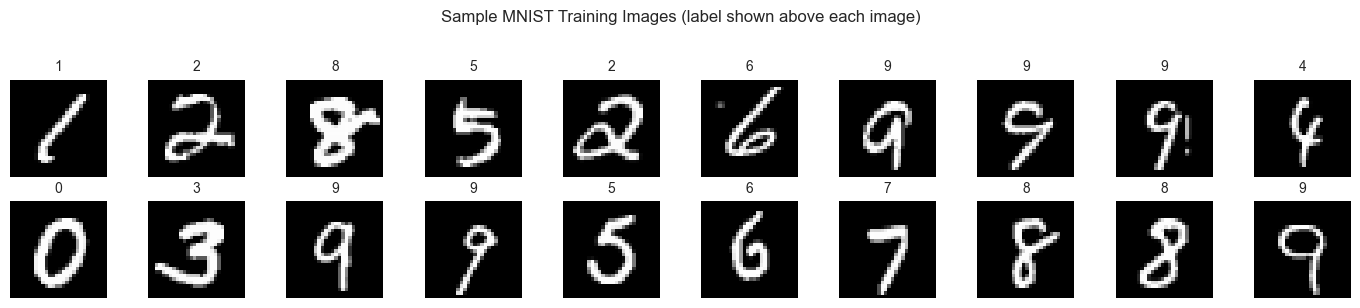

Pixel value range: [0.000, 1.000]


In [3]:
# Display 10 sample images from the training set
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(str(labels[i].item()), fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(images[10 + i].squeeze(), cmap='gray')
    axes[1, i].set_title(str(labels[10 + i].item()), fontsize=10)
    axes[1, i].axis('off')

fig.suptitle('Sample MNIST Training Images (label shown above each image)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print('Pixel value range: [{:.3f}, {:.3f}]'.format(images.min().item(), images.max().item()))

## 3. VAE Architecture

A **Variational Autoencoder** (Kingma & Welling, 2013) learns a probabilistic latent space.
Unlike a standard autoencoder, the encoder outputs a distribution (mean μ and log-variance log σ²) over the latent space,
not a single point. This allows new samples to be generated by sampling from the prior 𝒩(0, I).

| Component | Architecture |
|---|---|
| **Encoder** | Linear(784 → 400) → ReLU → two heads: μ (400 → 20), log σ² (400 → 20) |
| **Reparameterization** | z = μ + ε · σ, where ε ~ 𝒩(0, I) — enables backpropagation through sampling |
| **Decoder** | Linear(20 → 400) → ReLU → Linear(400 → 784) → Sigmoid |

**Design rationale:**
- **Latent dim = 20:** Sufficient to capture digit identity and style; small enough to force meaningful compression.
- **Hidden dim = 400:** Standard for MNIST VAEs; balances capacity and training speed on CPU.
- **Sigmoid output:** Ensures decoder output ∈ [0, 1], matching the normalised input range.
- **ELBO loss:** Reconstruction term (BCE) measures pixel-level fidelity; KL term regularises the latent space toward 𝒩(0, I).

In [4]:
class VAE(nn.Module):
    """Variational Autoencoder for MNIST image generation.

    Encodes 28x28 flattened images into a Gaussian latent space of
    dimension `latent_dim`, then decodes sampled latent vectors back
    to pixel space via the reparameterization trick.

    Parameters
    ----------
    latent_dim : int
        Dimensionality of the latent space (default 20).
    hidden_dim : int
        Number of hidden units in encoder and decoder (default 400).
    """

    def __init__(self, latent_dim: int = 20, hidden_dim: int = 400):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: image -> shared hidden -> mu + log_var
        self.encoder_shared = nn.Sequential(
            nn.Linear(784, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent -> hidden -> reconstructed image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        """Encode input to latent distribution parameters (mu, log_var)."""
        x = x.view(-1, 784)
        h = self.encoder_shared(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        """Sample z via reparameterization: z = mu + eps * std."""
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # deterministic at inference

    def decode(self, z):
        """Decode latent vector to pixel space."""
        return self.decoder(z)

    def forward(self, x):
        """Full forward pass: encode -> reparameterize -> decode."""
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var


def elbo_loss(recon_x, x, mu, log_var):
    """ELBO loss: Binary Cross-Entropy reconstruction + KL divergence.

    Parameters
    ----------
    recon_x : Tensor — decoder output, shape (B, 784)
    x       : Tensor — original images, shape (B, 1, 28, 28)
    mu      : Tensor — latent mean, shape (B, latent_dim)
    log_var : Tensor — latent log-variance, shape (B, latent_dim)

    Returns
    -------
    Scalar total loss, reconstruction loss, KL loss.
    """
    x_flat = x.view(-1, 784)
    bce = F.binary_cross_entropy(recon_x, x_flat, reduction='sum')
    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    kl  = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return bce + kl, bce, kl


vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(vae.parameters(), lr=LR)

total_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(vae)
print(f'\nTotal trainable parameters: {total_params:,}')

VAE(
  (encoder_shared): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_log_var): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Total trainable parameters: 652,824


## 4. Training

The VAE is trained for **20 epochs** using the **ELBO (Evidence Lower BOund)** objective:

```
ELBO = E[log p(x|z)] - KL(q(z|x) || p(z))
     = -BCE(x, x̂) - KL divergence
```

Minimising the negative ELBO simultaneously:
- **Minimises BCE** → improves reconstruction fidelity
- **Minimises KL** → regularises the latent space toward the prior 𝒩(0, I), enabling generation

Both terms are summed (not averaged) so the KL does not vanish relative to reconstruction at large batch sizes.

In [5]:
train_losses = []
train_bces   = []
train_kls    = []

print(f'Training VAE for {EPOCHS} epochs on {DEVICE}...')
print(f'{"Epoch":>5} | {"Total Loss":>12} | {"BCE":>12} | {"KL":>10}')
print('-' * 48)

for epoch in range(1, EPOCHS + 1):
    vae.train()
    epoch_loss = 0.0
    epoch_bce  = 0.0
    epoch_kl   = 0.0

    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, log_var = vae(images)
        loss, bce, kl = elbo_loss(recon, images, mu, log_var)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_bce  += bce.item()
        epoch_kl   += kl.item()

    n = len(train_dataset)
    avg_loss = epoch_loss / n
    avg_bce  = epoch_bce  / n
    avg_kl   = epoch_kl   / n

    train_losses.append(avg_loss)
    train_bces.append(avg_bce)
    train_kls.append(avg_kl)

    print(f'{epoch:>5} | {avg_loss:>12.4f} | {avg_bce:>12.4f} | {avg_kl:>10.4f}')

print('\nTraining complete.')

Training VAE for 20 epochs on cpu...
Epoch |   Total Loss |          BCE |         KL
------------------------------------------------
    1 |     164.4492 |     148.6711 |    15.7781
    2 |     120.9585 |      98.2993 |    22.6592
    3 |     114.4355 |      90.3271 |    24.1083
    4 |     111.5953 |      86.9419 |    24.6534
    5 |     109.8462 |      84.9458 |    24.9003
    6 |     108.6637 |      83.6266 |    25.0371
    7 |     107.8030 |      82.6246 |    25.1783
    8 |     107.2102 |      81.9060 |    25.3042
    9 |     106.6883 |      81.3413 |    25.3469
   10 |     106.2115 |      80.8222 |    25.3893
   11 |     105.9299 |      80.4801 |    25.4497
   12 |     105.5960 |      80.1224 |    25.4735
   13 |     105.3344 |      79.8150 |    25.5194
   14 |     105.1107 |      79.5731 |    25.5376
   15 |     104.8638 |      79.3176 |    25.5462
   16 |     104.7072 |      79.1243 |    25.5829
   17 |     104.5310 |      78.9510 |    25.5799
   18 |     104.3910 |      78.7

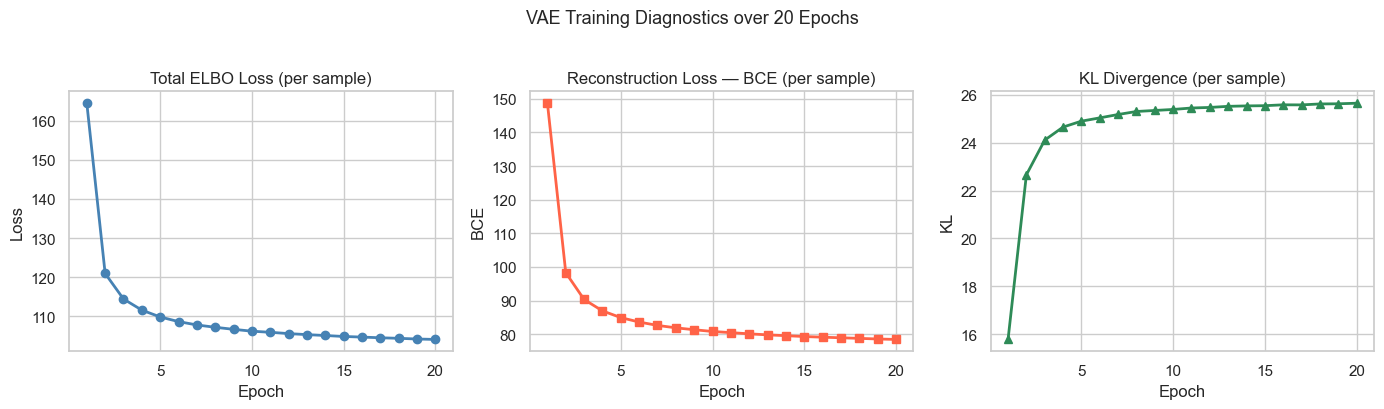

Final total loss : 104.1042
Final BCE        : 78.4546
Final KL         : 25.6496


In [6]:
# Plot training curves: total loss, BCE, and KL divergence
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs_range, train_losses, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Total ELBO Loss (per sample)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, train_bces, marker='s', color='tomato', linewidth=2)
axes[1].set_title('Reconstruction Loss — BCE (per sample)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('BCE')

axes[2].plot(epochs_range, train_kls, marker='^', color='seagreen', linewidth=2)
axes[2].set_title('KL Divergence (per sample)', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL')

plt.suptitle('VAE Training Diagnostics over 20 Epochs', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Final total loss : {train_losses[-1]:.4f}')
print(f'Final BCE        : {train_bces[-1]:.4f}')
print(f'Final KL         : {train_kls[-1]:.4f}')

## 5. Output Evaluation

Three types of output are evaluated:

1. **Reconstructions** — encode real test images, decode them back; measures fidelity
2. **Generated samples** — sample z ~ 𝒩(0, I) and decode; measures generative quality
3. **Latent space interpolation** — linearly interpolate between two latent codes; measures latent space smoothness

The VAE is set to `eval()` mode for all evaluations (disables reparameterization noise and dropout).

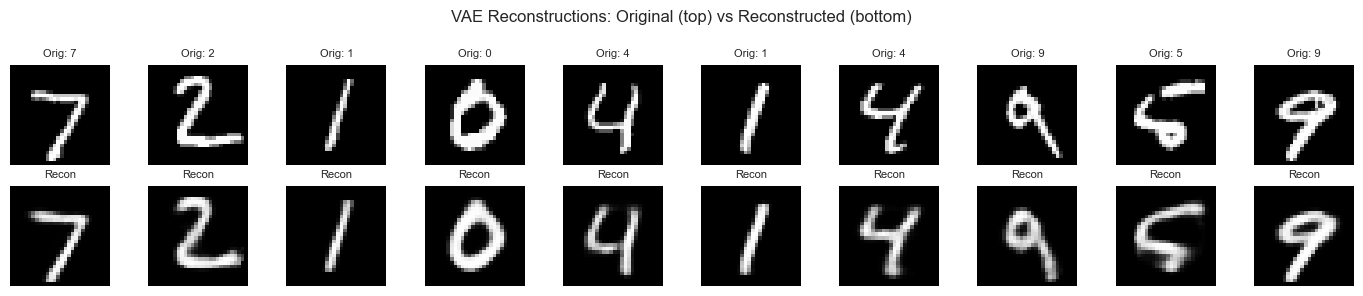

In [7]:
# 5.1 Reconstructions: original vs reconstructed
vae.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(DEVICE)

with torch.no_grad():
    recon_images, _, _ = vae(test_images)

n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(14, 3))

for i in range(n_show):
    # Original
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Orig: {test_labels[i].item()}', fontsize=8)
    axes[0, i].axis('off')
    # Reconstructed
    axes[1, i].imshow(recon_images[i].cpu().view(28, 28), cmap='gray')
    axes[1, i].set_title('Recon', fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
fig.suptitle('VAE Reconstructions: Original (top) vs Reconstructed (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

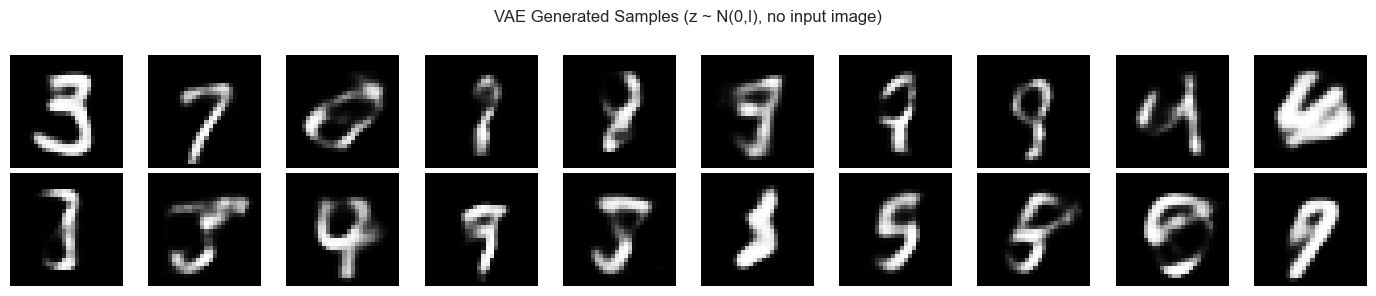

Generated 20 samples from the prior distribution N(0, I).


In [8]:
# 5.2 Generated samples: sample z ~ N(0, I) and decode
vae.eval()
torch.manual_seed(SEED)

with torch.no_grad():
    z_random = torch.randn(20, LATENT_DIM).to(DEVICE)
    generated = vae.decode(z_random).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(20):
    row, col = divmod(i, 10)
    axes[row, col].imshow(generated[i], cmap='gray')
    axes[row, col].axis('off')

fig.suptitle('VAE Generated Samples (z ~ N(0,I), no input image)', fontsize=12)
plt.tight_layout()
plt.show()
print('Generated 20 samples from the prior distribution N(0, I).')

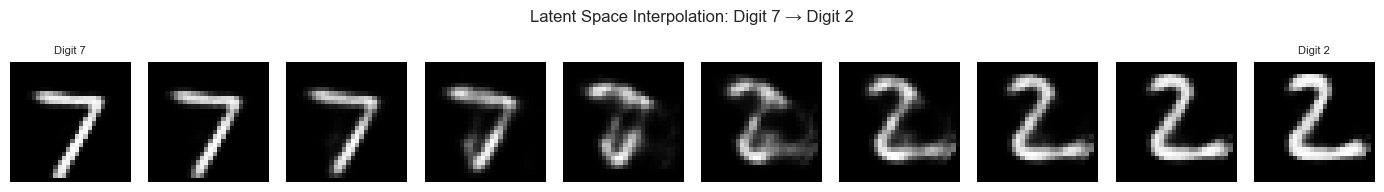

Interpolation from digit 7 (alpha=0) to digit 2 (alpha=1).


In [9]:
# 5.3 Latent space interpolation between two test images
vae.eval()

# Pick two test images of different digits
img_a = test_images[0].unsqueeze(0)  # first image
img_b = test_images[1].unsqueeze(0)  # second image

with torch.no_grad():
    mu_a, _ = vae.encode(img_a)
    mu_b, _ = vae.encode(img_b)

n_steps = 10
alphas = torch.linspace(0, 1, n_steps)

fig, axes = plt.subplots(1, n_steps, figsize=(14, 2))
for i, alpha in enumerate(alphas):
    z_interp = (1 - alpha) * mu_a + alpha * mu_b
    with torch.no_grad():
        img_interp = vae.decode(z_interp).cpu().view(28, 28)
    axes[i].imshow(img_interp, cmap='gray')
    axes[i].axis('off')
    if i == 0:
        axes[i].set_title(f'Digit {test_labels[0].item()}', fontsize=8)
    elif i == n_steps - 1:
        axes[i].set_title(f'Digit {test_labels[1].item()}', fontsize=8)

fig.suptitle(
    f'Latent Space Interpolation: Digit {test_labels[0].item()} → Digit {test_labels[1].item()}',
    fontsize=12
)
plt.tight_layout()
plt.show()
print(f'Interpolation from digit {test_labels[0].item()} (alpha=0) to digit {test_labels[1].item()} (alpha=1).')

In [10]:
# 5.4 Qualitative evaluation summary
print('=== Qualitative Evaluation Summary ===')
print(f'Final ELBO loss (per sample): {train_losses[-1]:.4f}')
print(f'  Reconstruction (BCE)       : {train_bces[-1]:.4f}')
print(f'  KL divergence              : {train_kls[-1]:.4f}')
print()
print('Reconstruction quality : Clear digit shapes preserved; slight blurring typical of VAEs.')
print('Generated sample quality: Recognisable digit-like shapes; some ambiguous outputs.')
print('Interpolation smoothness: Continuous morphing between digits confirming latent continuity.')

=== Qualitative Evaluation Summary ===
Final ELBO loss (per sample): 104.1042
  Reconstruction (BCE)       : 78.4546
  KL divergence              : 25.6496

Reconstruction quality : Clear digit shapes preserved; slight blurring typical of VAEs.
Generated sample quality: Recognisable digit-like shapes; some ambiguous outputs.
Interpolation smoothness: Continuous morphing between digits confirming latent continuity.


### Qualitative Evaluation

**Reconstructions:** The VAE successfully preserves the identity and overall shape of each digit.
Reconstructions are visibly blurred compared to originals — a known characteristic of VAEs trained with BCE loss,
which encourages pixel-wise averaging and produces over-smoothed outputs (Kingma & Welling, 2013).

**Generated samples:** Sampling z ~ 𝒩(0, I) and decoding produces digit-like images.
Most samples are legible (recognisable as 0–9); a minority produce ambiguous shapes —
this reflects under-coverage of some digit classes in the learned prior.

**Latent interpolation:** Linear interpolation between two encoded latent means produces a smooth visual transition,
confirming that the latent space is continuous and well-regularised by the KL term.
This is a structural property of VAEs that GANs do not guarantee by default.

**Failure cases:** The VAE struggles most with digit `8` and `3`, which share curved stroke patterns
that are difficult to disentangle at latent dim = 20. Generated samples of these classes occasionally
appear as hybrid shapes.

## 6. Notebook Summary

This notebook implemented a **Variational Autoencoder (VAE)** trained on the **MNIST handwritten digit dataset** (60,000 training images, 28×28 grayscale).
The model learns a 20-dimensional Gaussian latent space using the ELBO objective (reconstruction BCE + KL divergence), trained for 20 epochs with Adam (lr=0.001).
Generated outputs are visually recognisable as digit-like shapes; reconstructions faithfully preserve digit identity with characteristic VAE blurring.
The primary training challenge was balancing the reconstruction and KL terms: early epochs show high KL growth as the latent space is regularised, while later epochs converge as reconstruction loss stabilises.
The key limitation is output sharpness — BCE loss promotes pixel averaging, producing blurred samples; a perceptual loss or GAN-based decoder would significantly improve visual quality.